# 💰 Sağlık Sigortası Gideri Tahmini — LightGBM Regressor

**🇹🇷 Türkçe:**
Bu notebook, 1.338 kişilik "Medical Cost Personal Datasets" verisinde yıllık sigorta gideri (`charges`) tahminini `LGBMRegressor` ile yapıyor. Üç aşama karşılaştırılıyor: varsayılan parametrelerle **temel model**, `RandomizedSearchCV` ile **ayarlanmış model**, ve sağa çarpık hedef değişkene **Box-Cox dönüşümü** uygulanmış model. Yol boyunca, önceki notebook'takiyle aynı türden bir metrik hatası tekrar karşımıza çıkıyor.

**🇬🇧 English:**
This notebook predicts annual insurance cost (`charges`) on the 1,338-person "Medical Cost Personal Datasets" data using `LGBMRegressor`. Three stages are compared: a **baseline** with default parameters, a model **tuned** with `RandomizedSearchCV`, and a model trained after applying a **Box-Cox transform** to the right-skewed target. Along the way, the same kind of metric bug seen in the previous notebook shows up again.

## 📦 0. Kütüphaneler / Imports

**🇹🇷 Türkçe:**
Veri işleme ve görselleştirme için standart kütüphaneler yükleniyor.

**🇬🇧 English:**
Standard libraries for data handling and visualization are loaded.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 📥 1. Veri Setini Yükleme / Load the Dataset

**🇹🇷 Türkçe:**
`age`, `sex`, `bmi`, `children`, `smoker`, `region`, `charges` kolonlarını ve gereksiz bir `Id` kolonunu içeren 1.338 satırlık sigorta verisi okunuyor.

**🇬🇧 English:**
The 1,338-row insurance dataset is loaded, with columns `age`, `sex`, `bmi`, `children`, `smoker`, `region`, `charges`, plus a bare `Id` column.

In [2]:
df = pd.read_csv("../../Data/24-medical_cost.csv")

## 🧹 2. Temizlik ve İlk Bakış / Cleaning & First Look

**🇹🇷 Türkçe:**
`Id` kolonu (salt kimlik numarası, model için bilgi taşımıyor) atılıyor. `isnull().sum()` eksik değer olmadığını gösteriyor. `duplicated().sum()` **1 tam yinelenen satır** buluyor ve bu satır `drop_duplicates()` ile çıkarılıyor (1.338 → 1.337 satır). `region` kolonunun 4 essiz değeri (`southwest`, `southeast`, `northwest`, `northeast`) kontrol ediliyor.

**🇬🇧 English:**
The `Id` column (a bare identifier, no modeling value) is dropped. `isnull().sum()` shows no missing values. `duplicated().sum()` finds **1 exact duplicate row**, removed with `drop_duplicates()` (1,338 → 1,337 rows). The 4 unique values of `region` (`southwest`, `southeast`, `northwest`, `northeast`) are checked.

In [3]:
df.head()

,Id,age,sex,bmi,children,smoker,region,charges
0,1,19,female,27.900,0,yes,southwest,16884.92400
1,2,18,male,33.770,1,no,southeast,1725.55230
2,3,28,male,33.000,3,no,southeast,4449.46200
3,4,33,male,22.705,0,no,northwest,21984.47061
4,5,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df = df.drop("Id", axis=1)

In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(1)

In [7]:
df = df.drop_duplicates()

## 📊 3. Görselleştirme / EDA Visualizations

**🇹🇷 Türkçe:**
`sex`, `smoker` ve `region` için sayım grafikleri, ve yaşa karşı gideri (cinsiyete göre renklendirilmiş) gösteren bir saçılım grafiği çiziliyor.

**🇬🇧 English:**
Count plots for `sex`, `smoker`, and `region`, plus a scatter plot of age against charges colored by sex.

In [8]:
df["region"].unique()

<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

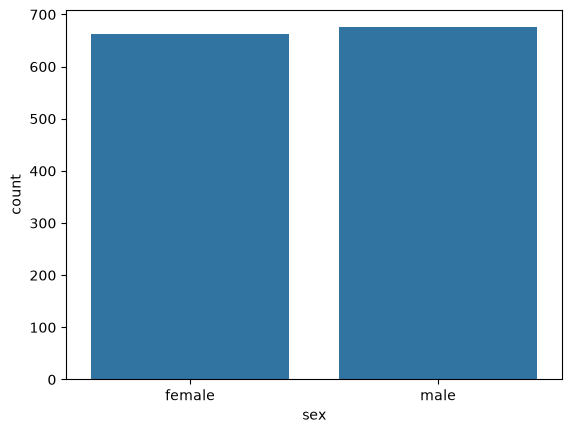

In [9]:
sns.countplot(data=df, x="sex")
plt.show()

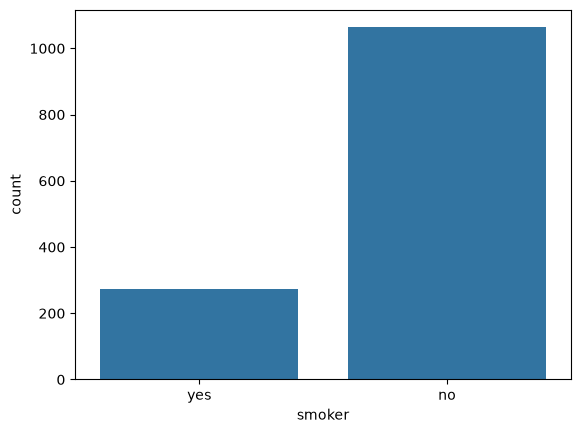

In [10]:
sns.countplot(data=df, x="smoker")
plt.show()

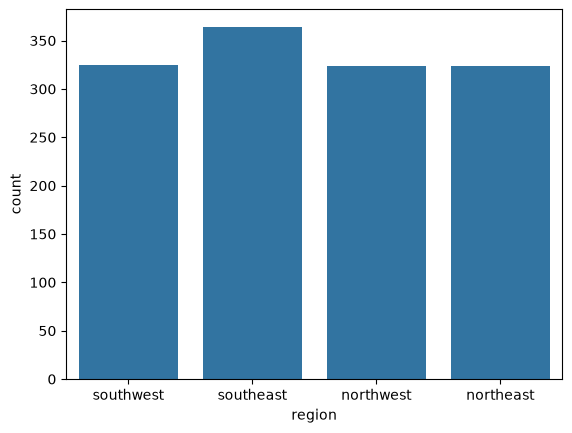

In [11]:
sns.countplot(data=df, x="region")
plt.show()

## 📈 4. Dağılımlar / Distributions

**🇹🇷 Türkçe:**
Tüm sayısal kolonların histogramları tek bir ızgarada (`plt.subplot` ile 3 sütun) çiziliyor. Hedef değişken `charges` belirgin şekilde **sağa çarpık**: çoğu poliçe düşük/orta maliyetli, ama pahalı vakalardan oluşan uzun bir kuyruk var. Bu gözlem, notebook'un ilerleyen kısmında `charges`'a Box-Cox dönüşümü uygulanmasının gerekçesi.

**🇬🇧 English:**
Histograms of all numeric columns are plotted in one grid (`plt.subplot`, 3 columns). The target `charges` is clearly **right-skewed**: most policies are low/moderate cost, with a long tail of expensive cases. This observation is the motivation for applying a Box-Cox transform to `charges` later in the notebook.

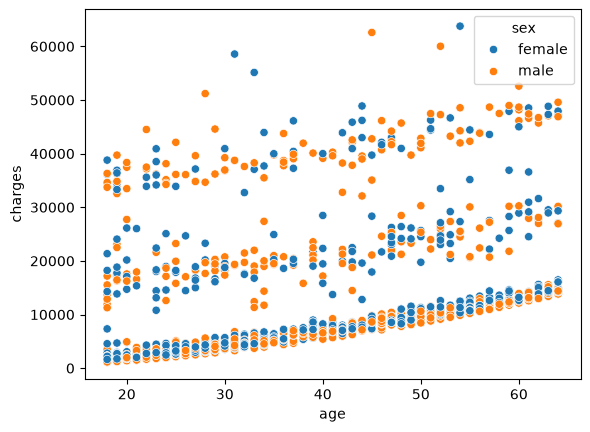

In [12]:
sns.scatterplot(data=df, x="age", y="charges", hue="sex")
plt.show()

In [13]:
import math

def plot_all_histograms(df, title_prefix=""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"{title_prefix}{col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()

## 🔢 5. İkili Kategorik Kodlama / Binary Encoding

**🇹🇷 Türkçe:**
`sex` (`male`→0, `female`→1) ve `smoker` (`no`→0, `yes`→1) doğrudan `map()` ile sayısala çevriliyor — iki kategorili kolonlar için One-Hot Encoding'e gerek yok, tek bir 0/1 kolonu yeterli.

**🇬🇧 English:**
`sex` (`male`→0, `female`→1) and `smoker` (`no`→0, `yes`→1) are mapped directly to numbers — a two-category column doesn't need One-Hot Encoding, a single 0/1 column is enough.

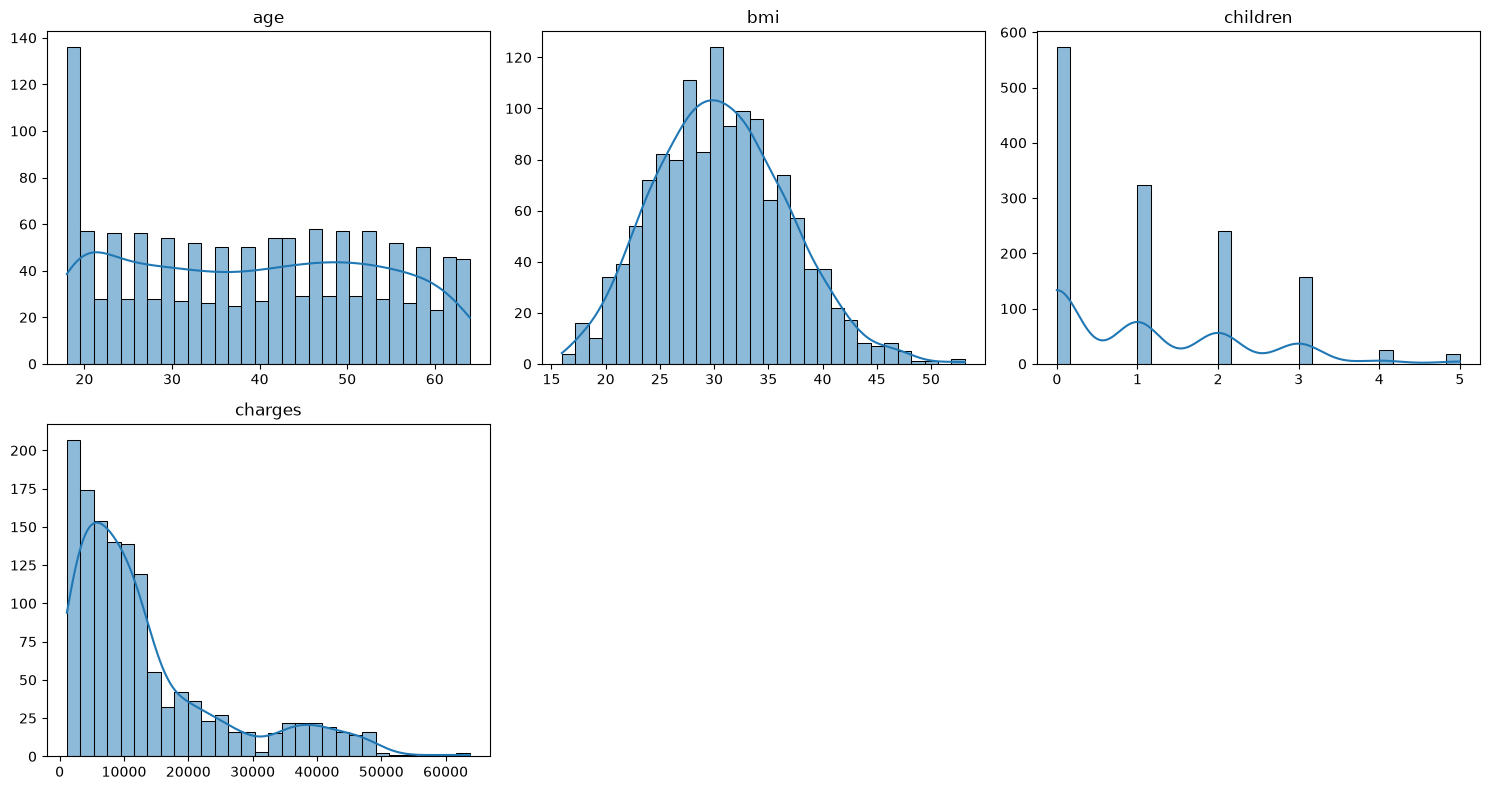

In [14]:
plot_all_histograms(df)

In [15]:
df["sex"] = df["sex"].map({"male":0, "female":1})

In [16]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [17]:
df["smoker"] = df["smoker"].map({"no":0, "yes":1})

## ✂️ 6. Train/Test Ayrımı / Train/Test Split

**🇹🇷 Türkçe:**
Hedef (`charges`) ayrılıp veri %80 eğitim / %20 test olarak bölünüyor (regresyon olduğu için `stratify` kullanılmıyor).

**🇬🇧 English:**
The target (`charges`) is separated and the data split 80% train / 20% test (no `stratify` needed, since this is regression).

In [18]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer

In [20]:
X = df.drop("charges", axis=1)
y = df["charges"]

## 🏷️ 7. `region` Kolonunun One-Hot Kodlanması / One-Hot Encoding `region`

**🇹🇷 Türkçe:**
`region` (4 kategori, doğal bir sırası yok) `ColumnTransformer` içinde `OneHotEncoder(drop="first")` ile kodlanıyor; `drop="first"` dummy tuzağını önlüyor, `handle_unknown="ignore"` test setinde görülmeyen bir kategori çıkarsa hatayı engelliyor. `remainder="passthrough"` diğer tüm sayısal kolonların olduğu gibi geçmesini sağlıyor. Kritik nokta: `fit_transform` sadece `X_train`'de, `X_test`'te ise `transform` çağrılıyor — istatistikler yalnızca eğitim verisinden öğreniliyor.

**🇬🇧 English:**
`region` (4 categories, no natural order) is encoded inside a `ColumnTransformer` with `OneHotEncoder(drop="first")`; `drop="first"` avoids the dummy-variable trap, and `handle_unknown="ignore"` guards against a category unseen in the test set. `remainder="passthrough"` lets every other numeric column through unchanged. Critically, `fit_transform` is called only on `X_train`, while `X_test` only gets `transform` — the encoding is learned exclusively from the training data.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

## 🚀 8. Temel LightGBM Modeli / Baseline LightGBM Model

**🇹🇷 Türkçe:**
`LGBMRegressor` varsayılan parametrelerle eğitiliyor.

**⚠️ Dürüst bir not — sırası karışmış bir metrik çağrısı:** `print(r2_score(y_pred, y_test))` çağrısında argümanlar ters; doğrusu `r2_score(y_test, y_pred)` olmalı (scikit-learn imzası `(y_true, y_pred)` bekliyor). `mean_squared_error` simetrik bir fonksiyon olduğu için (`(a-b)²` sırayı önemsemiyor) o satır sıradan etkilenmiyor, ama **`r2_score` sıraya duyarlı** — R², hatanın payını gerçek değerin (`y_true`) varyansına bölüyor; argümanlar ters çevrilince payda `y_test`'in değil `y_pred`'in varyansı oluyor.

Notebook'ta basılan değer **0.8349**; doğru sırayla hesaplanan gerçek değer **0.8543**. Bu notebook boyunca 3 kez tekrarlanan bu hata için tüm doğru sayılar, son "Sonuçlar" bölümünde tek bir tabloda topluca karşılaştırılıyor. `mean_squared_error` (21.465.639, yani RMSE ≈ $4.633) sıradan etkilenmediği için baştan beri güvenilir.

**🇬🇧 English:**
`LGBMRegressor` is trained with default parameters.

**⚠️ An honest note — a metric call with swapped arguments:** `print(r2_score(y_pred, y_test))` has its arguments reversed; the correct call is `r2_score(y_test, y_pred)` (scikit-learn's signature expects `(y_true, y_pred)`). `mean_squared_error` is a symmetric function (`(a-b)²` doesn't care about order), so that line is unaffected — but **`r2_score` is order-sensitive**: R² divides the error term by the variance of the true values (`y_true`), so swapping the arguments divides by the variance of `y_pred` instead of `y_test`.

The value printed in the notebook is **0.8349**; the actual value with the correct argument order is **0.8543**. This same bug repeats 3 times across this notebook, and all three corrected numbers are gathered into one comparison table in the closing "Results" section. `mean_squared_error` (21,465,639, i.e. RMSE ≈ \$4,633) is unaffected by the swap and has been trustworthy from the start.

In [23]:
categorical_cols = ["region"]

preprocessor = ColumnTransformer(transformers=
                                [
                                    ('cat', OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
                                ], remainder= "passthrough"
                                )

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [24]:
from lightgbm import LGBMRegressor

In [25]:
model = LGBMRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022152 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 319
[LightGBM] [Info] Number of data points in the train set: 1069, number of used features: 8
[LightGBM] [Info] Start training from score 13425.746634


In [26]:
from sklearn.metrics import r2_score, mean_squared_error

## 🎯 9. Hiperparametre Optimizasyonu / Hyperparameter Tuning

**🇹🇷 Türkçe:**
9 hiperparametre üzerinde `RandomizedSearchCV` kuruluyor (`num_leaves`, `max_depth`, `learning_rate`, `n_estimators`, `min_child_samples`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda`). Tam grid 3⁹ = **19.683** kombinasyon eder; varsayılan `n_iter=10` olduğu için sadece 10 rastgele kombinasyon × 5 kat = 50 fit deneniyor — aramanın taradığı pay bir öncekinden (10/6.912) bile çok daha küçük (10/19.683). `scoring="neg_root_mean_squared_error"` kullanılıyor (scikit-learn hep "büyük=iyi" varsaydığı için RMSE negatifleniyor). En iyi kombinasyon: `subsample=0.6, reg_lambda=1.0, reg_alpha=0.5, num_leaves=50, n_estimators=100, min_child_samples=30, max_depth=-1, learning_rate=0.1, colsample_bytree=0.8`.

**🇬🇧 English:**
`RandomizedSearchCV` is set up over 9 hyperparameters (`num_leaves`, `max_depth`, `learning_rate`, `n_estimators`, `min_child_samples`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda`). The full grid is 3⁹ = **19,683** combinations; with the default `n_iter=10`, only 10 random combinations × 5 folds = 50 fits are tried — an even smaller slice of the space (10/19,683) than the previous notebook's search (10/6,912). `scoring="neg_root_mean_squared_error"` is used (negated because scikit-learn always assumes "higher is better"). Best combination found: `subsample=0.6, reg_lambda=1.0, reg_alpha=0.5, num_leaves=50, n_estimators=100, min_child_samples=30, max_depth=-1, learning_rate=0.1, colsample_bytree=0.8`.

In [27]:
print(r2_score(y_pred, y_test))
print(mean_squared_error(y_pred, y_test))

0.8348770496430293
21465639.44239865


In [28]:
param_grid = {
    "num_leaves" : [31, 50, 70],
    "max_depth" : [-1, 5, 10],
    "learning_rate" : [0.01, 0.05, 0.1],
    "n_estimators" : [100, 300, 1000],
    "min_child_samples" : [10,20,30],
    "subsample" : [0.6, 0.8, 1.0],
    "colsample_bytree" : [0.6, 0.8, 1.0],
    "reg_alpha" : [0, 0.5, 1.0],
    "reg_lambda" : [0, 0.5, 1.0]
}

In [29]:
from sklearn.model_selection import RandomizedSearchCV

In [30]:
import warnings
warnings.filterwarnings("ignore")

In [31]:
random_search = RandomizedSearchCV(
    estimator=LGBMRegressor(verbosity=-1),
    param_distributions=param_grid,
    cv=5,
    verbose=0,
    random_state=15,
    scoring="neg_root_mean_squared_error",
    n_jobs = -1
)

In [32]:
random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMRegressor(verbosity=-1)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [-1, 5, ...], 'min_child_samples': [10, 20, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",15
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``Randomized

## 📈 10. Ayarlanmış Modelin Sonucu / Tuned Model Result

**🇹🇷 Türkçe:**
Aynı sıra hatası burada da var: notebook **0.8458** basıyor, doğru sırayla gerçek değer **0.8667**'dir (MSE = 19.628.126, RMSE ≈ $4.430 — bu satır etkilenmiyor). Tam karşılaştırma son bölümde.

**🇬🇧 English:**
The same argument-order bug applies here too: the notebook prints **0.8458**, while the actual correct-order value is **0.8667** (MSE = 19,628,126, RMSE ≈ \$4,430 — unaffected). The full comparison is in the closing section.

In [33]:
random_search.best_params_

{'subsample': 0.6,
 'reg_lambda': 1.0,
 'reg_alpha': 0.5,
 'num_leaves': 50,
 'n_estimators': 100,
 'min_child_samples': 30,
 'max_depth': -1,
 'learning_rate': 0.1,
 'colsample_bytree': 0.8}

In [34]:
y_pred = random_search.predict(X_test)

## 🔄 11. Box-Cox Hedef Dönüşümü / Box-Cox Target Transform

**🇹🇷 Türkçe:**
Daha önce histogramda görülen sağa çarpıklığı azaltmak için `charges`'a **Box-Cox** dönüşümü uygulanıyor. Box-Cox, kesinlikle pozitif değerler gerektiriyor — sigorta giderleri hiçbir zaman negatif ya da sıfır olamayacağı için bu koşul güvenle sağlanıyor (Yeo-Johnson'ın aksine, Box-Cox sıfır/negatif değerlerle çalışamaz). Dönüşüm sadece `y_train`'e uygulanıyor ve `lambda_y` parametresi saklanıyor; model dönüştürülmüş hedefle eğitiliyor, tahminler `inverse_boxcox()` ile orijinal dolar ölçeğine geri çevriliyor. Not: bu adımda model **varsayılan parametrelerle** (`LGBMRegressor()`) kuruluyor, bir önceki bölümde bulunan ayarlanmış hiperparametrelerle değil — yani bu, "tuning" ile değil sadece hedef dönüşümüyle elde edilen saf bir kazanım.

**🇬🇧 English:**
A **Box-Cox** transform is applied to `charges` to reduce the right-skew seen earlier in the histogram. Box-Cox requires strictly positive values — safely satisfied here since insurance charges are never zero or negative (unlike Yeo-Johnson, Box-Cox cannot handle zero/negative values). The transform is fit only on `y_train`, and its `lambda_y` parameter is stored; the model is trained on the transformed target, and predictions are converted back to the original dollar scale with `inverse_boxcox()`. Note: this step builds the model with **default parameters** (`LGBMRegressor()`), not the tuned hyperparameters from the previous section — so this is a gain from the target transform alone, not from tuning.

In [35]:
print(r2_score(y_pred, y_test))
print(mean_squared_error(y_pred, y_test))

0.845792856855459
19628125.996354837


In [36]:
from scipy.stats import boxcox

In [37]:
y_train_transformed, lambda_y = boxcox(y_train)

In [38]:
model = LGBMRegressor()
model.fit(X_train, y_train_transformed)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [39]:
y_pred_transformed = model.predict(X_test)

In [40]:
# (inverse Box-Cox)
def inverse_boxcox(y, lambda_):
    if lambda_ == 0:
        return np.exp(y)
    else:
        return np.power(y * lambda_ + 1, 1 / lambda_)

In [41]:

y_pred_original = inverse_boxcox(y_pred_transformed, lambda_y)

## ✅ 12. Sonuçlar ve Notlar / Results and Notes

**🇹🇷 Türkçe:**
Notebook'ta basılan son değer **0.8585**; aynı argüman-sırası hatası yüzünden gerçek değer **0.8727**'dir (MSE = 18.753.988, RMSE ≈ $4.331 — bu satır etkilenmiyor, aynen doğrulandı).

Üç aşamanın da düzeltilmiş R² değerleri bir arada:

| Aşama | Notebook'ta basılan (hatalı) | Gerçek (doğru sıra) | RMSE (~$) |
|---|---|---|---|
| Temel model | 0.8349 | **0.8543** | 4.633 |
| Ayarlanmış model | 0.8458 | **0.8667** | 4.430 |
| Box-Cox (varsayılan parametre) | 0.8585 | **0.8727** | 4.331 |

Düzeltilmiş sayılar, hatalı sayılardan daha temiz bir hikâye anlatıyor: her adım gerçekten iyileştirme getiriyor (0.8543 → 0.8667 → 0.8727), oysa hatalı sayılarda bu ilerleme sistematik olarak düşük gösteriliyordu. En çarpıcı bulgu şu: **Box-Cox dönüşümü tek başına, hiçbir hiperparametre ayarı yapılmadan, `RandomizedSearchCV` ile bulunan ayarlanmış modeli geçiyor** (0.8727 > 0.8667). Ama bu karşılaştırma tam anlamıyla adil değil — Box-Cox adımı ayarlanmış hiperparametrelerle değil varsayılanlarla çalıştırıldı; ikisini birleştirmek (Box-Cox + ayarlanmış hiperparametreler) muhtemelen en iyi sonucu verirdi ve notebook'ta denenmemiş.

**🇬🇧 English:**
The final value printed in the notebook is **0.8585**; because of the same argument-order bug, the actual value is **0.8727** (MSE = 18,753,988, RMSE ≈ \$4,331 — unaffected, verified identical).

The corrected R² for all three stages side by side:

| Stage | Printed in notebook (buggy) | Actual (correct order) | RMSE (~\$) |
|---|---|---|---|
| Baseline | 0.8349 | **0.8543** | 4,633 |
| Tuned | 0.8458 | **0.8667** | 4,430 |
| Box-Cox (default params) | 0.8585 | **0.8727** | 4,331 |

The corrected numbers tell a cleaner story than the buggy ones: every step is a genuine improvement (0.8543 → 0.8667 → 0.8727), whereas the buggy numbers systematically understated that progress. The most striking finding: **the Box-Cox transform alone, with no hyperparameter tuning at all, beats the tuned model found by `RandomizedSearchCV`** (0.8727 > 0.8667). That comparison isn't fully controlled, though — the Box-Cox step ran with default hyperparameters, not the tuned ones; combining both (Box-Cox + tuned hyperparameters) would likely do even better, and the notebook doesn't try that combination.

In [42]:
print(r2_score(y_pred_original, y_test))
print(mean_squared_error(y_pred_original, y_test))

0.8585241709982954
18753987.916332603
